# We analyze the data of AQI of different cities across the India.

## Data Assessing:

### DataSet Overview
This the data represents the AQI (Air Quality Index) of different cities. This AQI is measured over different parameters like: PM2.5, NOx, CO, SO2 etc with high reactive chemical substances like: Benzene, Toluene, Xylene with AQI and AQI bucket.
This data starting from january 2015 to july 2020 representing a 5 years dataset of AQI.

The following columns are present in this data:
- `City`: Different cities across India.
- `Date`: Date data is recorded on.(yyyy-mm-dd)
- `PM2.5`: Particulate matter(small dust particles) 2.5mm radius
- `PM10`: Particulate matter , 10mm radius
- `NO`: Nitrogen Oxide
- `NO2`: Nitrogen Dioxide
- `NOx`: Nitrogen oxides
- `NH3`: Nitrogen trihalide
- `CO`: Carbon Dioxide
- `SO2`: Sulphur Dioxide
- `O3`: Ozone
- `Benzene`: Reactive chemical substance
- `Toluene`: Reactive chemical substance
- `Xylene`: Reactive chemical substance
- `AQI`: Air Quality Index (air quality measurement unit)
- `AQI Bucket`: It groups a range of aqi into a simple color or health warnings.

### Issues with the Dataset:

1. Dirty Data:
    - PM2.5 col has many missing enteries `completion problem`
    - PM10 col has many missing enteries `completion problem`
    - NO col has missing enteries `completion problem`
    - NO2 col has missing enteries `completion problem`
    - NO2 col has missing enteries `completion problem`
    - NOx col has missing enteries `completion problem`
    - NH3 col has missing enteries `completion problem`
    - CO col has missing enteries `completion problem`
    - SO2 col has missing enteries `completion problem`
    - O3 col has missing enteries `completion problem`
    - Benzene col has missing enteries `completion problem`
    - Toluene col has missing enteries `completion problem`
    - Xylene col has missing enteries `completion problem`
    - AQI col has missing enteries `completion problem`
    - AQI_Bucket col has missing enteries `completion problem`
    - Many rows with no data `completion problem`

2. Messy Data:
    - There is nothing like messy data in this dataset.

### Data Cleaning

In [2]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('bmh')
sns.set_theme(palette='pastel')

In [3]:
df=pd.read_csv('./dataset/city_day.csv')
df

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29526,Visakhapatnam,2020-06-27,15.02,50.94,7.68,25.06,19.54,12.47,0.47,8.55,23.30,2.24,12.07,0.73,41.0,Good
29527,Visakhapatnam,2020-06-28,24.38,74.09,3.42,26.06,16.53,11.99,0.52,12.72,30.14,0.74,2.21,0.38,70.0,Satisfactory
29528,Visakhapatnam,2020-06-29,22.91,65.73,3.45,29.53,18.33,10.71,0.48,8.42,30.96,0.01,0.01,0.00,68.0,Satisfactory
29529,Visakhapatnam,2020-06-30,16.64,49.97,4.05,29.26,18.80,10.03,0.52,9.84,28.30,0.00,0.00,0.00,54.0,Satisfactory


In [4]:
df.shape

(29531, 16)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  str    
 1   Date        29531 non-null  str    
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  str    
dtypes: float64(13), str(3)
memory usage: 3.6 MB


In [6]:
# how many unique cities?
df['City'].nunique()

26

In [7]:
# what is the date range?
print(df['Date'].min())
print(df['Date'].max())

2015-01-01
2020-07-01


In [8]:
df.isnull().sum()

City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

In [9]:
# finding the percentage of missing data in each col
missing=(df.isnull().sum()/len(df))*100
missing.sort_values(ascending=False)

Xylene        61.322001
PM10          37.723071
NH3           34.973418
Toluene       27.229014
Benzene       19.041008
AQI           15.851139
AQI_Bucket    15.851139
PM2.5         15.570079
NOx           14.171549
O3            13.619586
SO2           13.050692
NO2           12.139785
NO            12.129626
CO             6.972334
Date           0.000000
City           0.000000
dtype: float64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000
mean,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
std,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585
min,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000
50%,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000
75%,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000
max,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000


* The describe function is not giving much insights.
* Many columns have missing values but we can't drop them or fill them with median as those columns directly affect the AQI, as AQI is formed from each columns' contribution.
* Many rows are completely blank afterwards 'city and 'date' col.

Removing the rows with no pollutants and aqi and aqi_bucket data

In [12]:
# Define: many rows are completely blank
# - removing them using dropna

import pandas as pd

data_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']

df = df.dropna(subset=data_cols, how='all')
df.isnull().sum()

City              0
Date              0
PM2.5          3224
PM10           9766
NO             2208
NO2            2211
NOx            2811
NH3            8954
CO              685
SO2            2480
O3             2648
Benzene        4249
Toluene        6667
Xylene        16735
AQI            3307
AQI_Bucket     3307
dtype: int64

significantly drop in NaN values

In [13]:
# converting all date to datetime format incase 'accuracy issue'
df['Date']=pd.to_datetime(df['Date'])

In [14]:
missing.sort_values(ascending=False)

Xylene        61.322001
PM10          37.723071
NH3           34.973418
Toluene       27.229014
Benzene       19.041008
AQI           15.851139
AQI_Bucket    15.851139
PM2.5         15.570079
NOx           14.171549
O3            13.619586
SO2           13.050692
NO2           12.139785
NO            12.129626
CO             6.972334
Date           0.000000
City           0.000000
dtype: float64

Here, we have strategy for filling the missing data:
* Case A: missing < 15%
    - Fill with median
    - NOx,O3,SO2,NO2,NO,CO

* Case B: missing < 15-40%
    - group median by city like: Delhi PM2.5 shouldn't fill in Mumbai's Median.
    - PM2.5,PM10,NH3,Toluene,Benzene

* Case C: missing > 40-50%
    - Drop the column
    - Xylene

* Case D: For AQI and AQI_Bucket:
    - This depends on all parameters, so we simply not touch it.

In [15]:
# converting city and aqi_bucket in categorical type
df['City']=df['City'].astype('category')
df['AQI_Bucket']=df['AQI_Bucket'].astype('category')

In [16]:
#Define: missing values in NOx,O3,SO2,NO2,NO,CO 
# - filling them using their median
cols_to_fill=["NOx","O3","SO2","NO2","NO","CO"]
df[cols_to_fill]=df[cols_to_fill].fillna(df[cols_to_fill].median())

In [17]:
# Define: missing values in PM2.5,PM10,NH3,Toluene,Benzene
# - filling them according to their cities
cols_to_fill=["PM2.5","PM10","NH3","Toluene","Benzene"]
df[cols_to_fill] = df.groupby("City")[cols_to_fill]\
.transform(lambda x: x.fillna(x.median()))

In [18]:
# Define: 60% missing value in Xylene
# - Dropping it as 60% missing contributes a little
df=df.drop(columns="Xylene")

In [19]:
df.isnull().sum()

City             0
Date             0
PM2.5            0
PM10          1991
NO               0
NO2              0
NOx              0
NH3           1559
CO               0
SO2              0
O3               0
Benzene       2488
Toluene       3623
AQI           3307
AQI_Bucket    3307
dtype: int64

Observing above table, we can see that instead of running fillna() with median , we are able to see sum values let's verify it

In [20]:
df.groupby("City")[cols_to_fill].apply(lambda x: x.isnull().sum())

,PM2.5,PM10,NH3,Toluene,Benzene
City,,,,,
Ahmedabad,0,0,1559,0,0
Aizawl,0,0,0,0,0
Amaravati,0,0,0,0,0
Amritsar,0,0,0,0,0
Bengaluru,0,0,0,0,0
Bhopal,0,0,0,280,280
Brajrajnagar,0,0,0,795,0
Chandigarh,0,0,0,0,0
Chennai,0,0,0,0,0


In [21]:
# So, for some cities whole pollutant column is missing, so we fill them with golabl median()
col = ["PM10", "NH3", "Benzene", "Toluene"]
df[col] = df[col].fillna(df[col].median())
df.isnull().sum()

City             0
Date             0
PM2.5            0
PM10             0
NO               0
NO2              0
NOx              0
NH3              0
CO               0
SO2              0
O3               0
Benzene          0
Toluene          0
AQI           3307
AQI_Bucket    3307
dtype: int64

now, data is cleaned very much

In [22]:
len(df)

28157

In [23]:
df['AQI'].count()

np.int64(24850)

In [24]:
df['AQI_Bucket'].count()

np.int64(24850)

In [25]:
df.info()

<class 'pandas.DataFrame'>
Index: 28157 entries, 0 to 29530
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   City        28157 non-null  category      
 1   Date        28157 non-null  datetime64[us]
 2   PM2.5       28157 non-null  float64       
 3   PM10        28157 non-null  float64       
 4   NO          28157 non-null  float64       
 5   NO2         28157 non-null  float64       
 6   NOx         28157 non-null  float64       
 7   NH3         28157 non-null  float64       
 8   CO          28157 non-null  float64       
 9   SO2         28157 non-null  float64       
 10  O3          28157 non-null  float64       
 11  Benzene     28157 non-null  float64       
 12  Toluene     28157 non-null  float64       
 13  AQI         24850 non-null  float64       
 14  AQI_Bucket  24850 non-null  category      
dtypes: category(2), datetime64[us](1), float64(12)
memory usage: 3.1 MB


In [26]:
df.describe()

,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,AQI
count,28157,28157.000000,28157.000000,28157.000000,28157.000000,28157.000000,28157.000000,28157.000000,28157.000000,28157.000000,28157.000000,28157.000000,24850.000000
mean,2018-05-24 13:17:57.941542,64.769030,111.259568,16.972113,28.021147,31.431678,22.117239,2.215546,14.058827,34.148035,2.934751,7.138259,166.463581
min,2015-01-01 00:00:00,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,13.000000
25%,2017-04-22 00:00:00,27.460000,61.650000,5.970000,12.480000,14.080000,10.770000,0.520000,5.940000,20.040000,0.180000,0.620000,81.000000
50%,2018-08-23 00:00:00,46.880000,96.755000,9.890000,21.690000,23.520000,14.870000,0.890000,9.160000,30.840000,1.020000,2.600000,118.000000
75%,2019-09-12 00:00:00,77.060000,128.150000,18.380000,35.780000,37.380000,27.670000,1.430000,14.290000,43.590000,2.670000,6.530000,208.000000
max,2020-07-01 00:00:00,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,2049.000000
std,NaN,61.739238,76.683345,21.971513,23.566723,30.140155,21.895682,6.880848,17.383551,20.677055,14.594661,17.696142,140.696585


In [27]:
df.groupby('City')["AQI"].max()

City
Ahmedabad             2049.0
Aizawl                  92.0
Amaravati              312.0
Amritsar               869.0
Bengaluru              352.0
Bhopal                 312.0
Brajrajnagar           355.0
Chandigarh             335.0
Chennai                449.0
Coimbatore             120.0
Delhi                  716.0
Ernakulam              180.0
Gurugram               891.0
Guwahati               956.0
Hyderabad              737.0
Jaipur                 457.0
Jorapokhar             604.0
Kochi                  277.0
Kolkata                475.0
Lucknow                707.0
Mumbai                 307.0
Patna                  619.0
Shillong               182.0
Talcher                570.0
Thiruvananthapuram     230.0
Visakhapatnam          387.0
Name: AQI, dtype: float64

In [28]:
cols=["PM2.5",	"PM10"	,"NO",	"NO2"	,"NOx"	,"NH3",	"CO",	"SO2",	"O3",	"Benzene"	,"Toluene",	"AQI"]
df.groupby('City')[cols].max()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,AQI
City,,,,,,,,,,,,
Ahmedabad,381.69,586.270,175.81,292.02,246.03,14.87,175.81,186.08,162.43,115.14,371.65,2049.0
Aizawl,54.90,62.860,20.36,2.85,25.15,36.73,0.60,13.53,30.84,81.92,82.01,92.0
Amaravati,139.38,230.270,43.76,140.17,103.49,35.20,1.84,66.39,138.18,53.89,76.32,312.0
Amritsar,868.66,917.080,103.44,237.27,150.96,129.46,3.83,67.26,66.70,26.09,30.21,869.0
Bengaluru,313.59,351.510,95.19,142.35,147.06,120.07,48.07,92.66,157.20,307.42,411.52,352.0
Bhopal,136.42,260.270,30.94,75.67,59.01,51.91,2.04,47.46,109.33,1.02,2.60,312.0
Brajrajnagar,308.79,589.390,390.68,41.07,382.84,194.46,4.77,24.97,97.06,299.61,2.60,355.0
Chandigarh,154.85,224.220,70.94,52.22,70.53,100.35,1.30,18.14,62.28,64.33,25.74,335.0
Chennai,293.43,346.730,59.44,112.29,77.57,352.89,20.62,50.51,105.13,391.88,265.98,449.0


The dataset contains several extreme pollutant and AQI observations. These values were retained because they may represent genuine high-pollution events rather than data entry errors. Removing them without evidence could bias the analysis.

In [29]:
# checking negative values
# Returns True if any value is negative, otherwise False
cols=["PM2.5",	"PM10"	,"NO",	"NO2"	,"NOx"	,"NH3",	"CO",	"SO2",	"O3",	"Benzene"	,"Toluene",	"AQI"]
has_negative = (df[cols] < 0).any()
print(has_negative)


PM2.5      False
PM10       False
NO         False
NO2        False
NOx        False
NH3        False
CO         False
SO2        False
O3         False
Benzene    False
Toluene    False
AQI        False
dtype: bool


no negative values entered in the numeric cols

### Data Analysis

1. Univariate Analysis

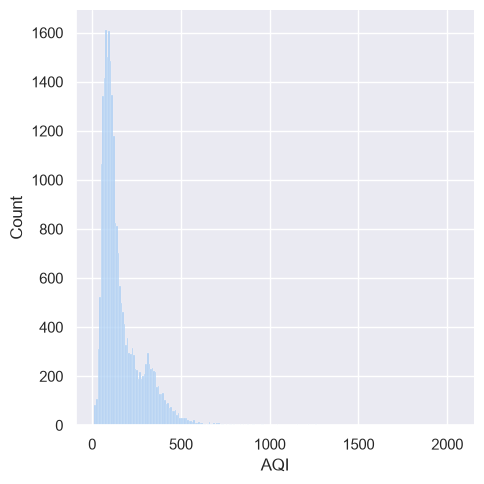

In [30]:
# Define: How is AQI distributed?
# - We make hist plot for this

sns.displot(data=df,kind='hist',x='AQI')

* Q. Distribution?
    - A: The AQI distribution is positively (right) skewed rather than perfectly normal. Most observations fall within lower to moderate AQI values, while a smaller number of extreme pollution events create a long right tail.

* Q. Right Skewed or Left Skewed?
    - A: Its right skewed guassin like curve

* Q. Multiple peaks?
    - A: No, One big peak only.

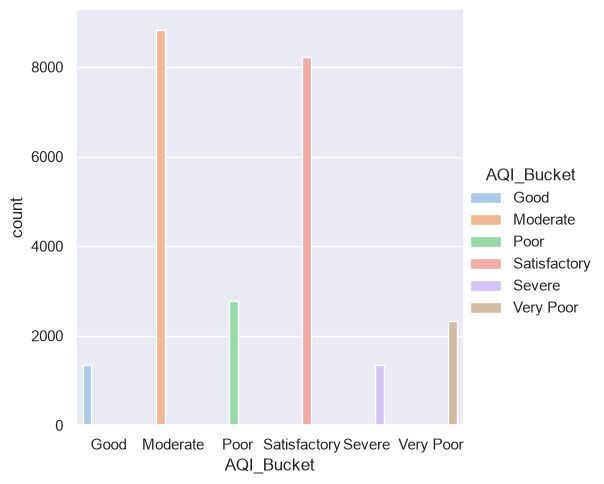

In [31]:
# Define: AQI_Bucket Distribution
# - We make countplot for this
plt.style.use('bmh')
sns.set_theme(palette='pastel')
sns.catplot(kind='count',data=df,x='AQI_Bucket',hue='AQI_Bucket')

* Q. Which AQI category occurs most frequently?
    - A: Moderate and Satisfactoy AQI category occured mostly, this represents that most of the Indian cities have moderate and satisfactory AQI conditions.

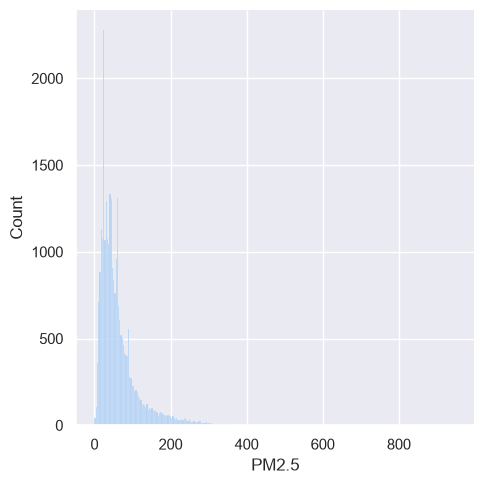

In [32]:
# Define: Distribution of pollutants
# - Histograms of each pollutant

# for pm2.5
sns.displot(kind='hist',data=df,x='PM2.5')

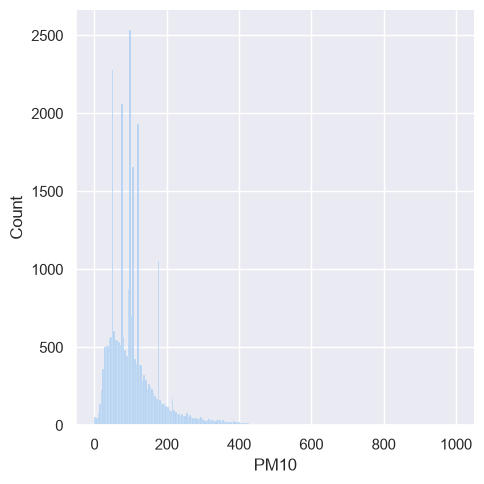

In [33]:
# for PM10
sns.displot(kind='hist',data=df,x='PM10')

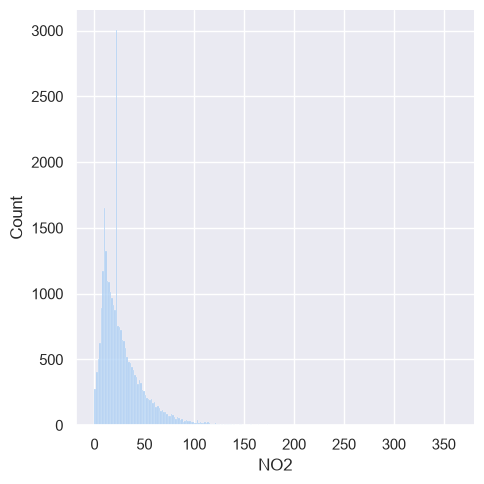

In [34]:
# for NO2
sns.displot(kind='hist',data=df,x='NO2')

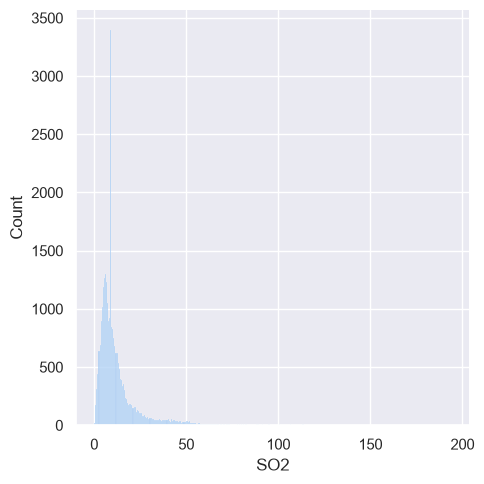

In [35]:
# for SO2
sns.displot(kind='hist',data=df,x='SO2')

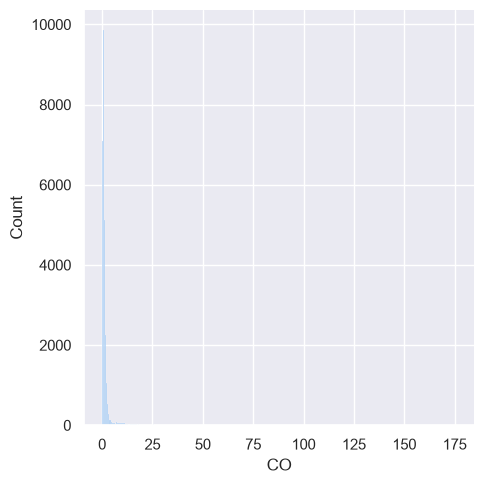

In [36]:
# for CO
sns.displot(kind='hist',data=df,x='CO')

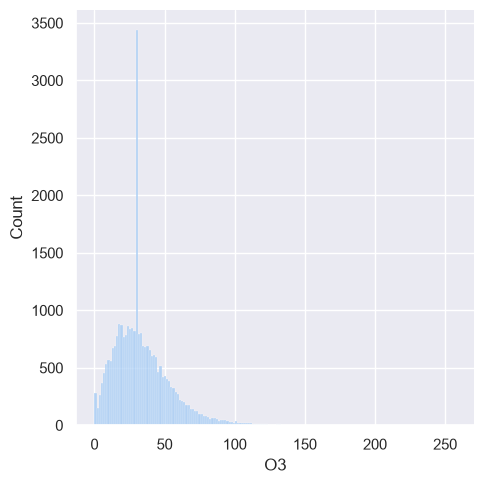

In [37]:
# for O3
sns.displot(kind='hist',data=df,x='O3')

* Q. Which pollutant has widest spread?
    - A: From observing the above graphs we can observe that "PM10" has widest spread. PM10 exhibits the widest distribution among all pollutants, indicating substantial variation in coarse particulate matter across Indian cities.

* Q. Which is highly Skewed?
    - A: Most of the graphs are right skewed that represents a guassian like curve.

In [38]:
df.groupby("City")['City'].value_counts().sort_values(ascending=False)

City
Delhi                 2009
Bengaluru             2008
Hyderabad             2003
Lucknow               1991
Mumbai                1989
Chennai               1989
Patna                 1709
Gurugram              1622
Ahmedabad             1559
Visakhapatnam         1429
Amritsar              1195
Jaipur                1108
Thiruvananthapuram    1099
Jorapokhar             947
Amaravati              897
Kolkata                814
Talcher                813
Brajrajnagar           795
Guwahati               502
Coimbatore             384
Chandigarh             304
Bhopal                 280
Shillong               277
Kochi                  162
Ernakulam              159
Aizawl                 113
Name: count, dtype: int64

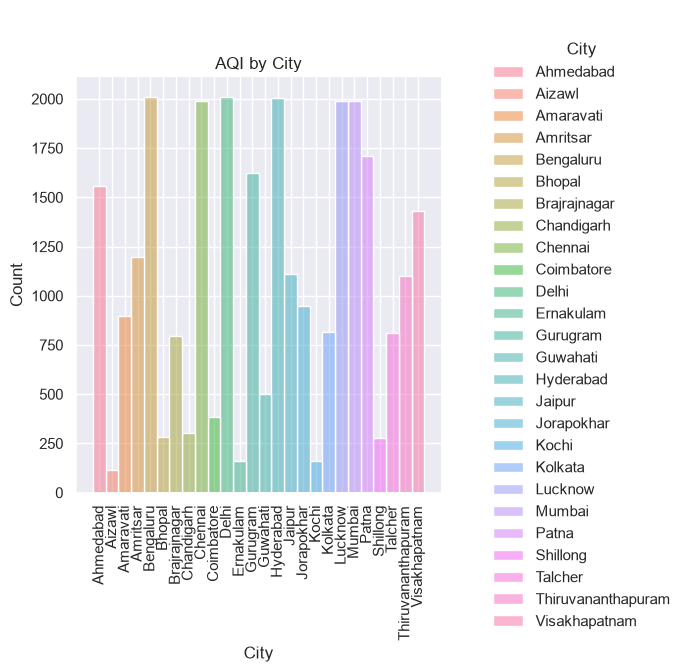

In [39]:
sns.displot(kind='hist',data=df,x='City',hue='City')
plt.title("AQI by City")
plt.xticks(rotation=90)
plt.show()

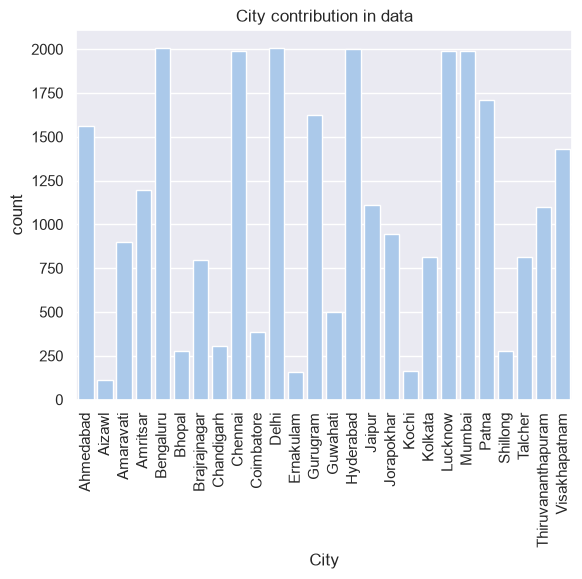

In [40]:
sns.countplot(data=df,x='City')
plt.title("City contribution in data")
plt.xticks(rotation=90)
plt.show()

* Q. Which City contributes the most
    - A: Delhi contributes the most, as it contains most data rows than other cities

2. Time Analysis

In [41]:
df['Year']=df['Date'].dt.year
df['Month']=df['Date'].dt.month_name()

In [42]:
# Define: AQI over years?
# - making line plot over years of AQI

df.groupby("Year")['AQI'].mean()

Year
2015    212.463054
2016    197.150019
2017    181.472789
2018    182.684312
2019    156.518173
2020    113.520697
Name: AQI, dtype: float64

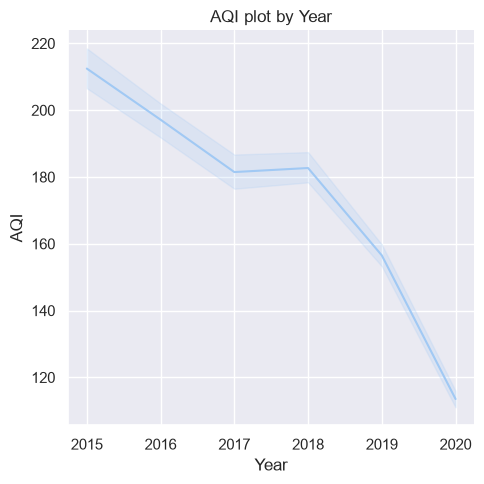

In [43]:
sns.relplot(data=df,kind='line',x='Year',y='AQI')
plt.title('AQI plot by Year')
plt.tight_layout()
plt.show()

* Q. Is air quality improving or worsening?
    - A: The average AQI shows an overall declining trend from 2015 to 2020, suggesting gradual improvements in air quality during the study period. However, this observation should be interpreted cautiously, as city coverage and data availability may vary across years.

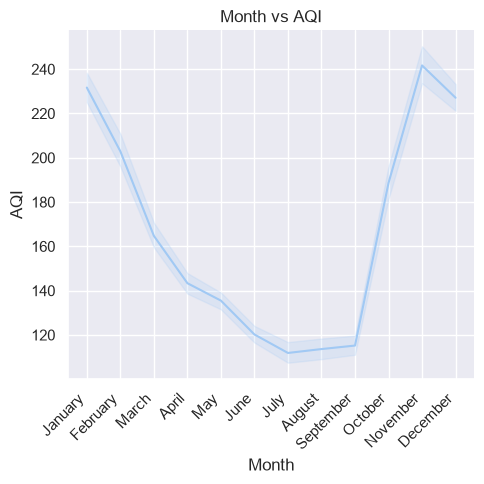

In [44]:
# Define: AQI by month
# - lineplot of month vs AQI
sns.relplot(data=df,kind='line',x='Month',y='AQI')
plt.title('Month vs AQI')
plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.show()

* Q. Which Month has the highest AQI?
    - A: From the above lineplot we clearly observes that two peaks are relatively higher which represents two months AQI. From observation we can say that 'November' & 'January' are approximately the months that had significantly high AQI recorded.

* Does AQI change with Seasons?
    - A: Yes, from the lineplot we can observe that significant rise in AQI in winter season(november,december,january).
    And significant fall in months like june,july,august,september as they are consisdered as 'Monsoon Season', so due to rainfall the pollutants settle down that elevates the air quality.

3. City-Wise Analysis

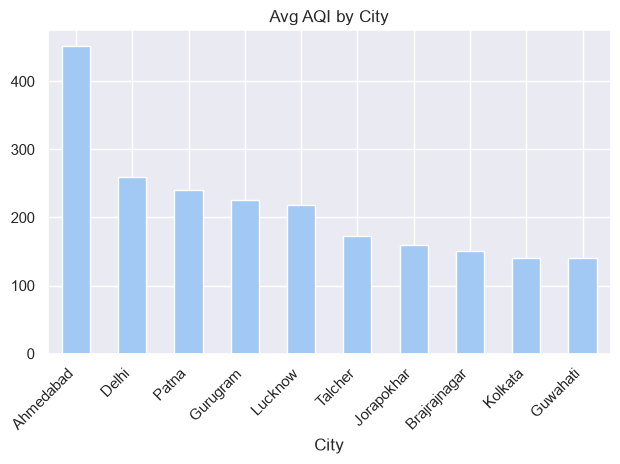

In [45]:
# Define: Cities with worst AQI?
# - sorting and making the barplot for City

df.groupby("City")["AQI"].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Avg AQI by City')
plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.show()

* Q. Which cities have the worst AQI?
    - A: From the above bar graph we can clearly observe that Ahmedabad has worst average AQI among all the cities following with Delhi, Patna, Gurugram and etc.

In [46]:
# Define: city recorded the highest AQI?
df.groupby('City')['AQI'].max()

City
Ahmedabad             2049.0
Aizawl                  92.0
Amaravati              312.0
Amritsar               869.0
Bengaluru              352.0
Bhopal                 312.0
Brajrajnagar           355.0
Chandigarh             335.0
Chennai                449.0
Coimbatore             120.0
Delhi                  716.0
Ernakulam              180.0
Gurugram               891.0
Guwahati               956.0
Hyderabad              737.0
Jaipur                 457.0
Jorapokhar             604.0
Kochi                  277.0
Kolkata                475.0
Lucknow                707.0
Mumbai                 307.0
Patna                  619.0
Shillong               182.0
Talcher                570.0
Thiruvananthapuram     230.0
Visakhapatnam          387.0
Name: AQI, dtype: float64

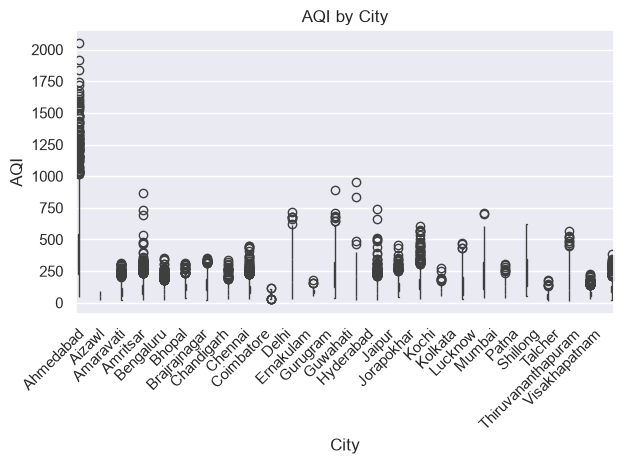

In [47]:
# Define: AQI distribution by city
# - Making the boxplot to observe the data

sns.boxplot(data=df,x='City',y='AQI',hue='City')
plt.title('AQI by City')
plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.show()

* Q. Which cities have the greatest variability?
    - A: Ahmedabad, Amritsar, Emakulam, Gurugram, Guwahati are among the top cities with greater variability relatively from the other cities mentioned here.

4. Pollutant Analysis

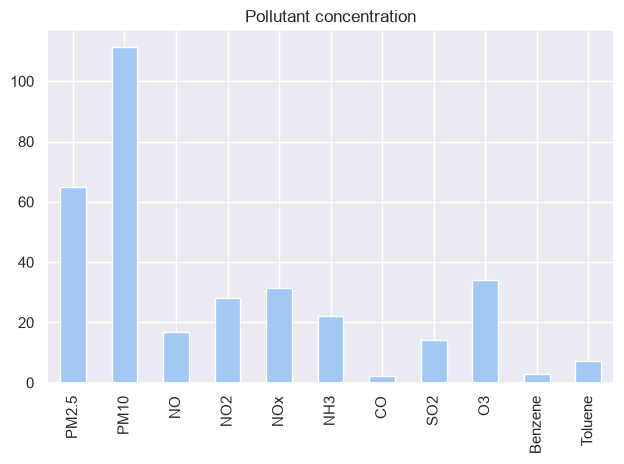

In [48]:
# Define: pollutant concentration analysis
# - making a bar graph for this
pollutants=["PM2.5",	"PM10"	,"NO",	"NO2"	,"NOx"	,"NH3",	"CO",	"SO2",	"O3",	"Benzene"	,"Toluene"]
df[pollutants].mean().plot(kind='bar')
plt.title('Pollutant concentration')
plt.tight_layout()
plt.show()

* Q. Which pollutant has highest average concentration?
    - A: PM10 has significantly high concentration among all the pollutants. PM10 means fine dirt particles suspended in Air.

In [49]:
df[pollutants].std()

PM2.5      61.739238
PM10       76.683345
NO         21.971513
NO2        23.566723
NOx        30.140155
NH3        21.895682
CO          6.880848
SO2        17.383551
O3         20.677055
Benzene    14.594661
Toluene    17.696142
dtype: float64

* Q. Which pollutant varies the most?
    - A: PM2.5 varies the most among all pollutants.

Text(0.5, 1.0, 'PM2.5 vs AQI')

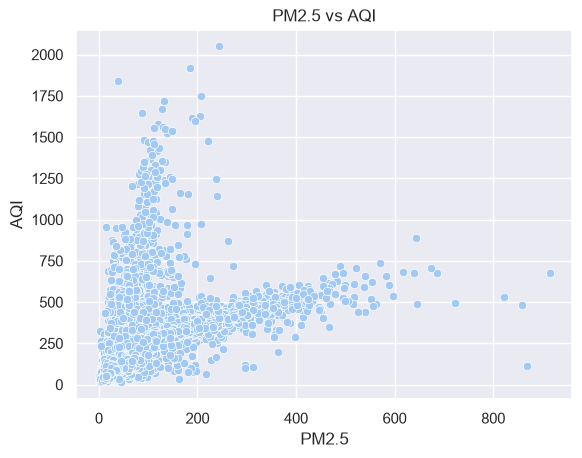

In [50]:
# Define: As pm2.5 varies the most then its relationship with AQI
# - Making a scatter plot

sns.scatterplot(data=df,x='PM2.5',y='AQI')
plt.title("PM2.5 vs AQI")

* Q. Does AQI increases as PM2.5 increases?
    - A: AQI increases rapidly with PM2.5 concentration at lower ranges. Beyond approximately 200 unit, the increase becomes less pronounced, suggesting a nonlinear relationship or saturation effect in the observed data.

Text(0.5, 1.0, 'PM10 vs AQI')

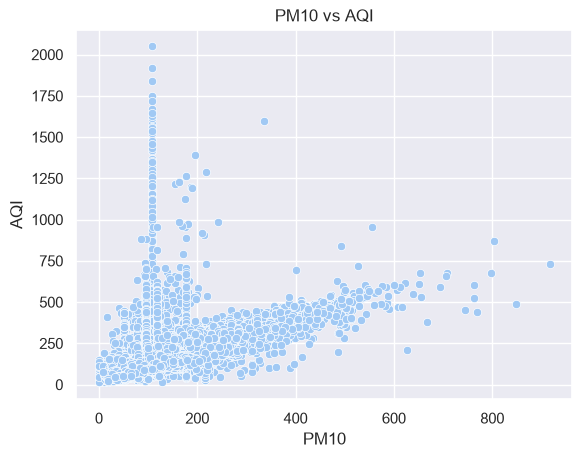

In [51]:
# Define: PM10 vs AQI

sns.scatterplot(data=df,x='PM10',y='AQI')
plt.title("PM10 vs AQI")

* Q. Does AQI increases as PM10 increases?
    - A: Seeing the scatterplot trend, we observe that first when increasing the pm10 concentration in air the, there was a sudden rise in AQI, but when a pm10 become above 200+ then AQI level tending to saturation.

Text(0.5, 1.0, 'PM10 vs AQI')

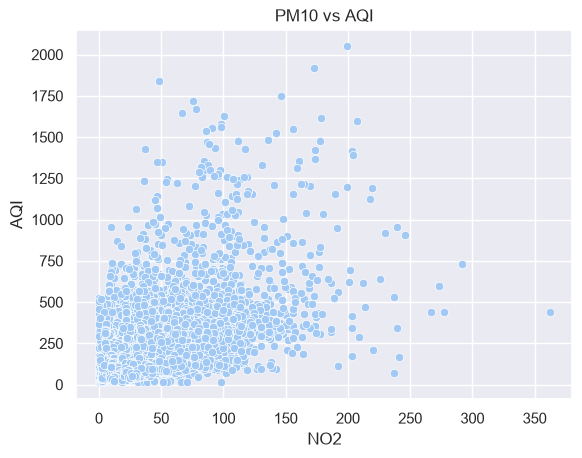

In [52]:
# Define: NO2 vs AQI

sns.scatterplot(data=df,x='NO2',y='AQI')
plt.title("PM10 vs AQI")

* Q. Does AQI increases as NO2 increases?
    - A: Seeing the scatterplot trend, we observe that the AQI is almost concentrated in one region with increase in NO2 in air.

5. Heatmap

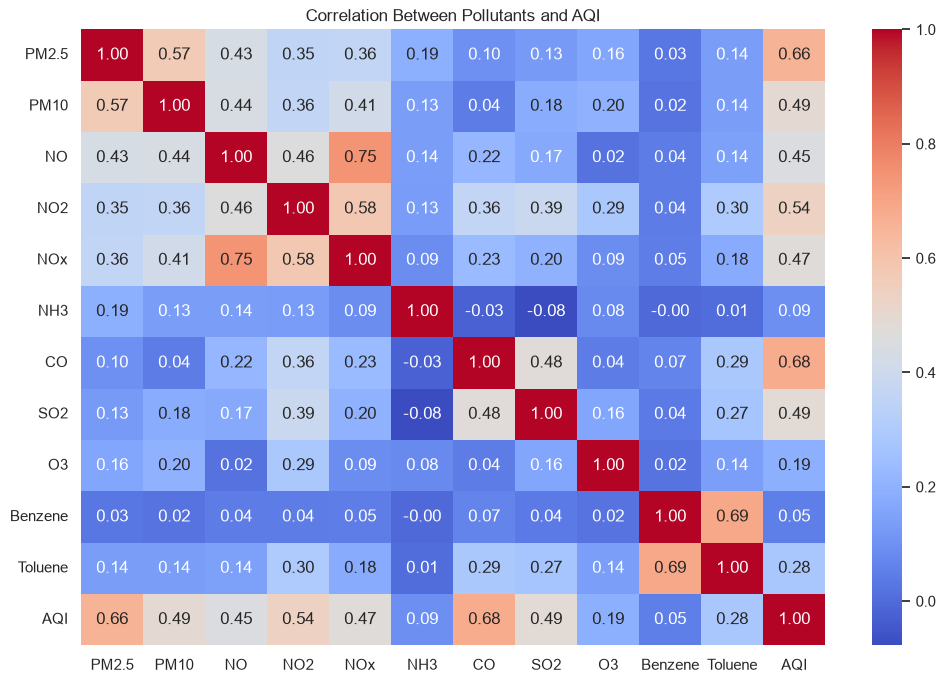

In [53]:
num_cols = [
    "PM2.5",
    "PM10",
    "NO",
    "NO2",
    "NOx",
    "NH3",
    "CO",
    "SO2",
    "O3",
    "Benzene",
    "Toluene",
    "AQI"
]
corr = df[num_cols].corr()
plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Pollutants and AQI")
plt.show()

Correlations:
* PM2.5 has the strongest positive correlation with AQI.
* PM10 is also strongly positively correlated with AQI.
* NO₂ and NOx are highly correlated because they originate from similar emission sources.
* Benzene and Toluene show a moderate positive correlation.

Text(0.5, 1.0, 'AQI by Year plot with city')

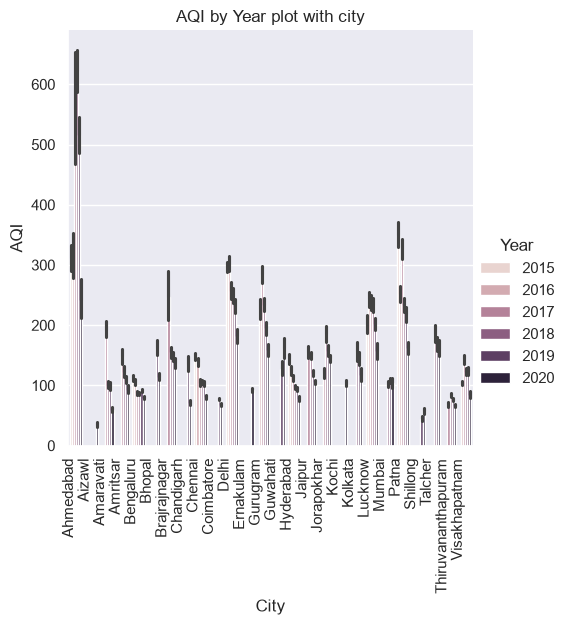

In [54]:
# Define: Which city improved the most?

sns.catplot(data=df,x='City', y='AQI',hue='Year',kind='bar')
plt.xticks(rotation=90,ha='right')
plt.title("AQI by Year plot with city")

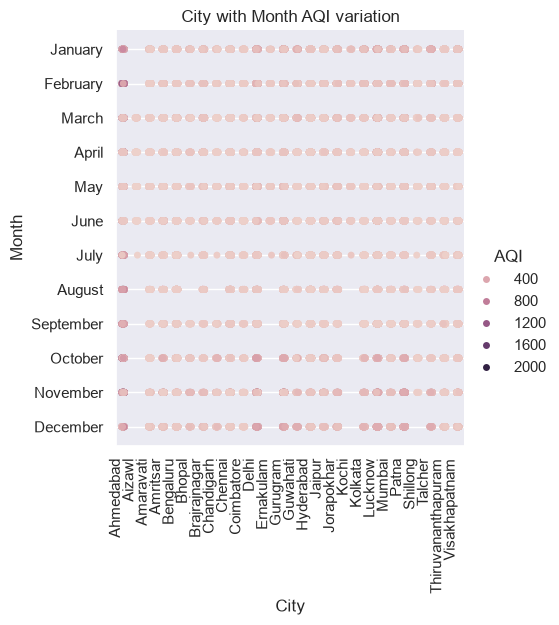

In [55]:
sns.catplot(data=df,x='City',y='Month',hue='AQI',kind='strip')
plt.xticks(rotation=90,ha='right')
plt.title("City with Month AQI variation")
plt.show()

In [56]:
n1=df.groupby('City')['AQI'].std().sort_values(ascending=False)

In [57]:
n2=df.groupby('City')['AQI'].mean().sort_values(ascending=False)

In [58]:
# Which city remained consistently polluted?
# std+mean of aqi
m=n1+n2
m.sort_values(ascending=False)

City
Ahmedabad             763.852492
Delhi                 379.025077
Patna                 363.123742
Gurugram              345.067112
Lucknow               334.935846
Talcher               277.754804
Guwahati              252.866291
Kolkata               245.058846
Jorapokhar            243.950302
Brajrajnagar          220.650753
Amritsar              196.888635
Bhopal                188.828167
Jaipur                187.988500
Visakhapatnam         172.161518
Chennai               166.469753
Hyderabad             162.350155
Chandigarh            153.679153
Mumbai                152.758698
Amaravati             151.361052
Kochi                 138.333126
Bengaluru             134.233258
Ernakulam             111.747351
Thiruvananthapuram    104.274505
Coimbatore             91.087105
Shillong               82.197983
Aizawl                 54.735723
Name: AQI, dtype: float64

## Key Findings

1. **`Overall Air Quality:`**
* The dataset contains daily air quality observations from multiple Indian cities spanning 2015–2020.
* Most observations fall within the Moderate and Satisfactory AQI categories.
* AQI values exhibit a right-skewed distribution, indicating occasional extreme pollution events.

2. **`City-wise Findings:`**
* Ahmedabad recorded the highest average AQI among all cities in the dataset.
* Delhi contributed the largest number of observations, making it the most represented city.
* Cities such as Ahmedabad, Gurugram, Amritsar, Guwahati, and Ernakulam exhibited the greatest variability in AQI levels.

3. **`Pollutant Insights:`**
* PM10 had the highest average concentration among all measured pollutants.
* PM2.5 showed the strongest positive correlation with AQI, indicating it is a major contributor to poor air quality.
* PM10 also demonstrated a strong relationship with AQI.
* NO2 and NOx displayed strong mutual correlation, reflecting their common emission sources.

4. **`Seasonal Trends:`**
* Air pollution peaks during the winter months (November–January).
* AQI decreases significantly during the monsoon season (June–September), likely due to rainfall removing airborne particulate matter.

5. **`Correlation Analysis:`**
* PM2.5 has the strongest positive correlation with AQI.
* PM10 is the second most influential pollutant.
* Benzene and Toluene exhibit moderate positive correlation.
* Pollutants originating from vehicular emissions tend to correlate with each other.

## Recommendations:
* Priority pollution control measures should focus on cities with consistently high AQI, such as `Ahmedabad` and `Delhi`.
* Strategies to reduce `PM2.5` and `PM10` emissions are likely to have the greatest impact on improving air quality.
* Additional preventive measures should be implemented during winter months when pollution levels peak.
* Continuous monitoring and targeted interventions are recommended for cities exhibiting `high AQI` variability.

In [59]:
# exporting the clean csv
df = df.reset_index(drop=True)
df.to_csv("cleaned_aqi_dataset.csv", index=False, encoding="utf-8")